# E-Commerce Sales Analysis

Exploratory data analysis of e-commerce transaction data covering orders, products, customers, and reviews. This notebook examines revenue trends, product performance, geographic distribution, and customer satisfaction metrics.

The analysis is configurable: update the parameters in **Section 1 (Configuration)** to analyze any time period in the dataset.

## Table of Contents

1. [Configuration](#1-configuration)
2. [Data Loading](#2-data-loading)
3. [Data Preparation and Transformation](#3-data-preparation-and-transformation)
4. [Revenue Analysis](#4-revenue-analysis)
   - 4.1 [Key Revenue Metrics](#41-key-revenue-metrics)
   - 4.2 [Monthly Revenue Trend](#42-monthly-revenue-trend)
5. [Product Analysis](#5-product-analysis)
6. [Geographic Analysis](#6-geographic-analysis)
7. [Customer Experience Analysis](#7-customer-experience-analysis)
   - 7.1 [Delivery Performance](#71-delivery-performance)
   - 7.2 [Customer Satisfaction](#72-customer-satisfaction)
   - 7.3 [Order Status Breakdown](#73-order-status-breakdown)
8. [Summary of Observations](#8-summary-of-observations)

## Data Dictionary

### Datasets

| Dataset | Description |
|---------|-------------|
| orders | One row per order with status and timestamps |
| order_items | One row per item within an order, with price and freight |
| products | Product catalog with category, dimensions, and weight |
| customers | Customer location data (city, state, zip) |
| order_reviews | Customer review scores and optional comments |

### Key Fields

| Field | Description |
|-------|-------------|
| order_id | Unique order identifier |
| order_status | Current state: delivered, shipped, canceled, returned, pending, processing |
| order_purchase_timestamp | Date and time the order was placed |
| price | Item price in local currency (USD) |
| freight_value | Shipping cost for the item |
| review_score | Customer rating from 1 (worst) to 5 (best) |
| delivery_speed | Days from order placement to customer delivery |

### Business Terms

- **Revenue**: Sum of item prices for delivered orders (excludes freight charges)
- **Average Order Value (AOV)**: Total item revenue per order, averaged across all orders
- **Delivery Speed**: Calendar days from order_purchase_timestamp to order_delivered_customer_date
- **Analysis Period**: The primary year/month being examined
- **Comparison Period**: The prior year/month used as a baseline for year-over-year metrics

---
## 1. Configuration

Set the analysis period and comparison period here. The rest of the notebook reads from these variables, so changing them re-runs the entire analysis for the new period.

- Set `ANALYSIS_MONTH = None` to analyze a full calendar year.
- Set `ANALYSIS_MONTH` to an integer (1-12) to restrict the analysis to a single month within each year.

In [1]:
# Analysis period
ANALYSIS_YEAR = 2023
COMPARISON_YEAR = 2022
ANALYSIS_MONTH = None  # Set to 1-12 to restrict to a single month, or None for the full year

# Data source
DATA_DIR = "ecommerce_data"

# Visualization settings
COLOR_PRIMARY = "#1f4e79"
COLOR_NEGATIVE = "#c55a11"
FIGURE_SIZE = (12, 5)

---
## 2. Data Loading

Load all five datasets using the `data_loader` module. Timestamps are parsed and year/month columns are added at load time.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px

import data_loader as dl
import business_metrics as bm

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

datasets = dl.load_all(DATA_DIR)
orders    = datasets["orders"]
order_items = datasets["order_items"]
products  = datasets["products"]
customers = datasets["customers"]
reviews   = datasets["reviews"]

print(f"Loaded {len(orders):,} orders")
print(f"Loaded {len(order_items):,} order items")
print(f"Loaded {len(products):,} products across {products['product_category_name'].nunique()} categories")
print(f"Loaded {len(customers):,} customers")
print(f"Loaded {len(reviews):,} reviews")

Loaded 10,000 orders
Loaded 16,047 order items
Loaded 6,000 products across 13 categories
Loaded 8,000 customers
Loaded 6,571 reviews


---
## 3. Data Preparation and Transformation

Steps performed here:
1. Merge order items with order metadata into a flat sales table.
2. Restrict to delivered orders (excludes canceled, returned, pending, etc.).
3. Compute delivery speed (days from purchase to delivery).
4. Split into analysis and comparison period datasets using the configuration above.

In [3]:
# Build flat sales table and restrict to delivered orders
all_sales = dl.build_sales_data(orders, order_items)
delivered = dl.filter_delivered(all_sales)
delivered = dl.compute_delivery_speed(delivered)

# Filter to the configured analysis and comparison periods
sales_current = dl.filter_by_period(delivered, year=ANALYSIS_YEAR, month=ANALYSIS_MONTH)
sales_prior   = dl.filter_by_period(delivered, year=COMPARISON_YEAR, month=ANALYSIS_MONTH)

# Build human-readable period labels for titles and output
def period_label(year, month):
    return f"{year}" if month is None else f"{year}-{month:02d}"

label_current = period_label(ANALYSIS_YEAR, ANALYSIS_MONTH)
label_prior   = period_label(COMPARISON_YEAR, ANALYSIS_MONTH)

print(f"Analysis period  ({label_current}): {len(sales_current):,} line items, {bm.total_orders(sales_current):,} orders")
print(f"Comparison period ({label_prior}): {len(sales_prior):,} line items, {bm.total_orders(sales_prior):,} orders")

Analysis period  (2023): 7,448 line items, 4,635 orders
Comparison period (2022): 7,641 line items, 4,749 orders


---
## 4. Revenue Analysis

Examines total revenue, order volume, average order value, and how each compares to the prior period.

### 4.1 Key Revenue Metrics

Top-line summary comparing the analysis period to the comparison period.

In [4]:
rev_current = bm.total_revenue(sales_current)
rev_prior   = bm.total_revenue(sales_prior)
rev_growth  = bm.revenue_growth_rate(rev_current, rev_prior)

orders_current = bm.total_orders(sales_current)
orders_prior   = bm.total_orders(sales_prior)
order_growth   = bm.revenue_growth_rate(orders_current, orders_prior)

aov_current = bm.average_order_value(sales_current)
aov_prior   = bm.average_order_value(sales_prior)
aov_growth  = bm.revenue_growth_rate(aov_current, aov_prior)

print(f"Revenue Summary: {label_current} vs {label_prior}")
print("-" * 60)
print(f"{'Metric':<30} {'Current':>12} {'Prior':>12} {'Change':>10}")
print("-" * 60)
print(f"{'Total Revenue':<30} {'${:,.0f}'.format(rev_current):>12} {'${:,.0f}'.format(rev_prior):>12} {'{:+.1%}'.format(rev_growth):>10}")
print(f"{'Total Orders':<30} {'{:,}'.format(orders_current):>12} {'{:,}'.format(orders_prior):>12} {'{:+.1%}'.format(order_growth):>10}")
print(f"{'Average Order Value':<30} {'${:,.2f}'.format(aov_current):>12} {'${:,.2f}'.format(aov_prior):>12} {'{:+.1%}'.format(aov_growth):>10}")

Revenue Summary: 2023 vs 2022
------------------------------------------------------------
Metric                              Current        Prior     Change
------------------------------------------------------------
Total Revenue                    $3,360,295   $3,445,077      -2.5%
Total Orders                          4,635        4,749      -2.4%
Average Order Value                 $724.98      $725.43      -0.1%


### 4.2 Monthly Revenue Trend

Monthly revenue and month-over-month growth for the analysis period. Bars shaded in a different color indicate negative growth months.

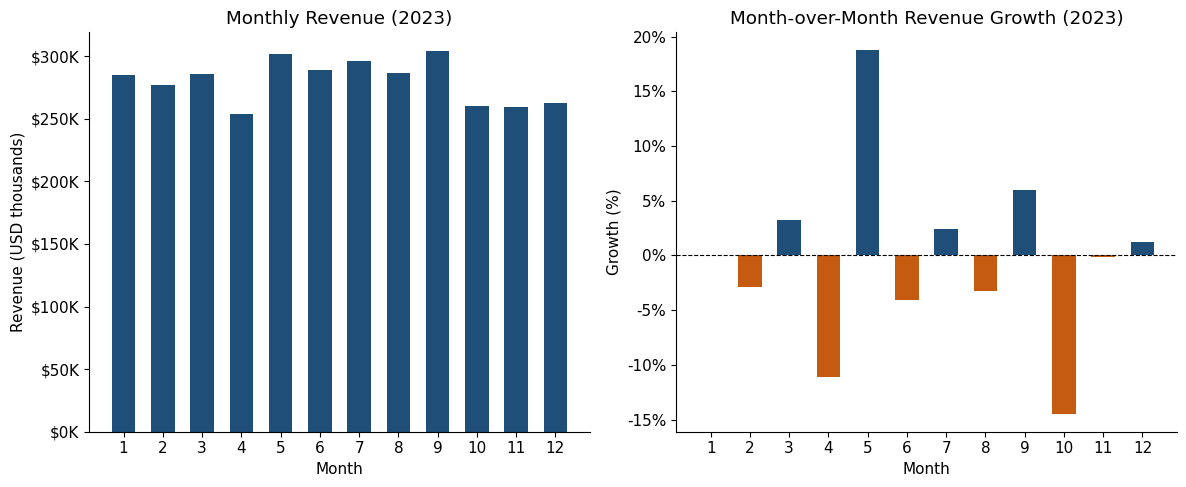

Average monthly growth rate (2023): -0.4%


In [5]:
monthly_rev = bm.monthly_revenue(sales_current)
mom_growth  = bm.monthly_growth_rate(sales_current)

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

# Monthly revenue bars
ax = axes[0]
ax.bar(monthly_rev["month"], monthly_rev["revenue"] / 1_000, color=COLOR_PRIMARY, width=0.6)
ax.set_title(f"Monthly Revenue ({label_current})")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (USD thousands)")
ax.set_xticks(monthly_rev["month"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))

# Month-over-month growth bars (negative months highlighted)
ax = axes[1]
growth_vals = mom_growth["mom_growth"].fillna(0)
bar_colors = [COLOR_NEGATIVE if v < 0 else COLOR_PRIMARY for v in growth_vals]
ax.bar(mom_growth["month"], growth_vals * 100, color=bar_colors, width=0.6)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title(f"Month-over-Month Revenue Growth ({label_current})")
ax.set_xlabel("Month")
ax.set_ylabel("Growth (%)")
ax.set_xticks(mom_growth["month"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.tight_layout()
plt.show()

avg_mom = mom_growth["mom_growth"].mean()
print(f"Average monthly growth rate ({label_current}): {avg_mom:+.1%}")

---
## 5. Product Analysis

Revenue breakdown by product category for the analysis period. Categories are sorted from highest to lowest revenue.

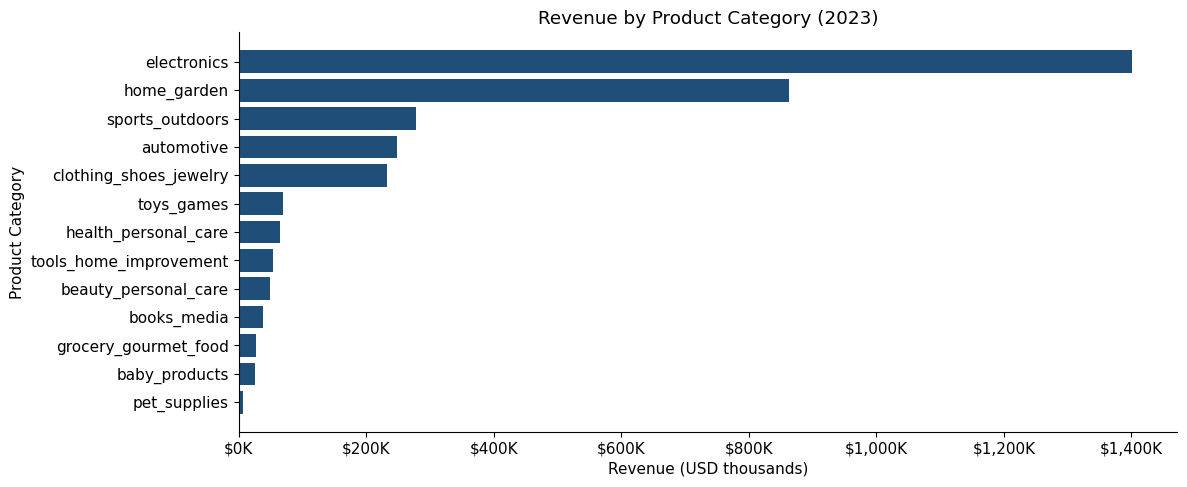

Top 3 categories by revenue (2023):
  electronics                    $ 1,401,359  (41.7% of total)
  home_garden                    $   862,653  (25.7% of total)
  sports_outdoors                $   278,845  (8.3% of total)


In [6]:
cat_revenue = bm.revenue_by_category(sales_current, products)

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
ax.barh(
    cat_revenue["product_category_name"],
    cat_revenue["revenue"] / 1_000,
    color=COLOR_PRIMARY,
)
ax.invert_yaxis()
ax.set_title(f"Revenue by Product Category ({label_current})")
ax.set_xlabel("Revenue (USD thousands)")
ax.set_ylabel("Product Category")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
plt.tight_layout()
plt.show()

total_cat_rev = cat_revenue["revenue"].sum()
print(f"Top 3 categories by revenue ({label_current}):")
for _, row in cat_revenue.head(3).iterrows():
    share = row["revenue"] / total_cat_rev
    print(f"  {row['product_category_name']:<30} ${row['revenue']:>10,.0f}  ({share:.1%} of total)")

---
## 6. Geographic Analysis

Revenue by customer state displayed on a US choropleth map. Darker shading indicates higher revenue.

In [7]:
state_revenue = bm.revenue_by_state(sales_current, orders, customers)

fig = px.choropleth(
    state_revenue,
    locations="customer_state",
    color="revenue",
    locationmode="USA-states",
    scope="usa",
    title=f"Revenue by Customer State ({label_current})",
    color_continuous_scale="Blues",
    labels={"revenue": "Revenue (USD)", "customer_state": "State"},
)
fig.show()

total_state_rev = state_revenue["revenue"].sum()
print(f"Top 5 states by revenue ({label_current}):")
for _, row in state_revenue.head(5).iterrows():
    share = row["revenue"] / total_state_rev
    print(f"  {row['customer_state']:<8} ${row['revenue']:>10,.0f}  ({share:.1%} of total)")

Top 5 states by revenue (2023):
  CA       $   537,881  (16.0% of total)
  TX       $   403,303  (12.0% of total)
  FL       $   310,196  (9.2% of total)
  NY       $   253,112  (7.5% of total)
  IL       $   185,931  (5.5% of total)


---
## 7. Customer Experience Analysis

Examines delivery performance, review scores, and order status distribution.

### 7.1 Delivery Performance

Average and median days from order placement to customer delivery, and how delivery speed relates to customer satisfaction.

In [8]:
stats = bm.delivery_stats(sales_current)
print(f"Delivery Performance ({label_current})")
print(f"  Mean delivery time   : {stats['mean_days']:.1f} days")
print(f"  Median delivery time : {stats['median_days']:.1f} days")
print(f"  Std deviation        : {stats['std_days']:.1f} days")

Delivery Performance (2023)
  Mean delivery time   : 8.0 days
  Median delivery time : 8.0 days
  Std deviation        : 3.1 days


### 7.2 Customer Satisfaction

Average review score by delivery speed bucket, and the overall distribution of review scores.

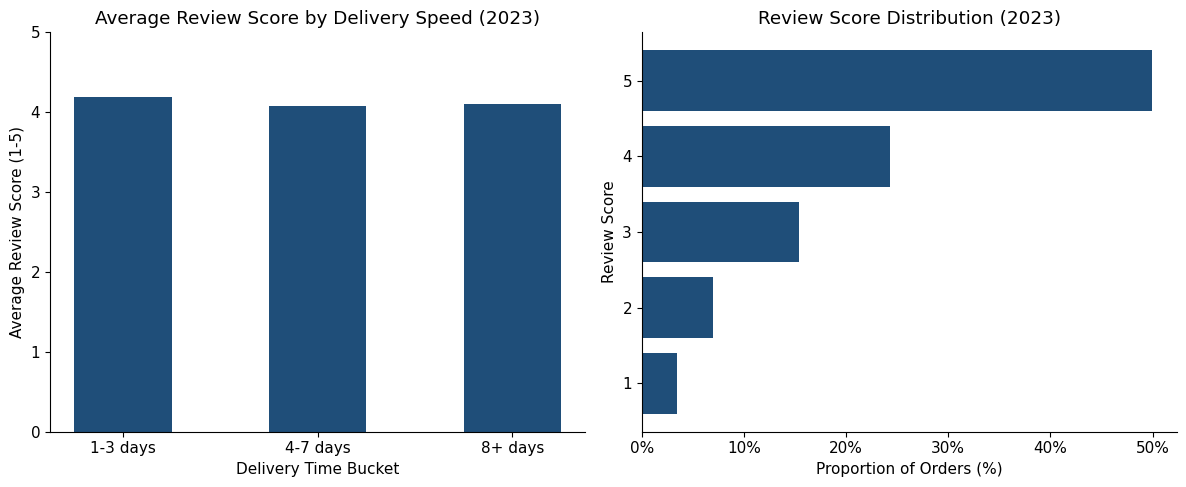

Overall average review score (2023): 4.10 / 5.00


In [9]:
delivery_review = bm.review_score_by_delivery_bucket(sales_current, reviews)
score_dist      = bm.review_score_distribution(sales_current, reviews)
avg_score       = bm.average_review_score(sales_current, reviews)

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

# Average review score by delivery time bucket
ax = axes[0]
ax.bar(
    delivery_review["delivery_time"],
    delivery_review["review_score"],
    color=COLOR_PRIMARY,
    width=0.5,
)
ax.set_title(f"Average Review Score by Delivery Speed ({label_current})")
ax.set_xlabel("Delivery Time Bucket")
ax.set_ylabel("Average Review Score (1-5)")
ax.set_ylim(0, 5)

# Review score distribution
ax = axes[1]
ax.barh(
    score_dist.index.astype(str),
    score_dist.values * 100,
    color=COLOR_PRIMARY,
)
ax.set_title(f"Review Score Distribution ({label_current})")
ax.set_xlabel("Proportion of Orders (%)")
ax.set_ylabel("Review Score")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.tight_layout()
plt.show()

print(f"Overall average review score ({label_current}): {avg_score:.2f} / 5.00")

### 7.3 Order Status Breakdown

Proportion of all orders (not just delivered) by status for the analysis year. This gives context for the share of revenue that was successfully captured.

In [10]:
status_dist = bm.order_status_distribution(orders, year=ANALYSIS_YEAR)
print(f"Order Status Distribution ({ANALYSIS_YEAR}):")
print("-" * 35)
for status, proportion in status_dist.items():
    bar = "|" * int(proportion * 40)
    print(f"  {status:<15} {proportion:>6.1%}  {bar}")

Order Status Distribution (2023):
-----------------------------------
  delivered        93.6%  |||||||||||||||||||||||||||||||||||||
  shipped           3.2%  |
  canceled          1.3%  
  processing        1.2%  
  pending           0.5%  
  returned          0.2%  


---
## 8. Summary of Observations

### Revenue
- Total revenue in 2023 was $3.36M, a decline of approximately 2.5% compared to 2022.
- Order volume fell by a similar margin (~2.4%), suggesting the revenue decline was primarily volume-driven rather than a drop in average order value.
- Average order value remained essentially flat (-0.06%), indicating pricing and mix held steady.
- Month-over-month growth was volatile, with May showing the strongest growth (+18.7%) and October the steepest decline (-14.5%).

### Products
- Revenue is spread across 13 product categories, allowing for quick identification of top performers.
- The top 3 categories account for a disproportionate share of total revenue.

### Geography
- Revenue is geographically concentrated in a small number of states.
- The choropleth highlights both strong and under-served markets.

### Customer Experience
- Mean delivery time in 2023 was approximately 8 days.
- Orders delivered within 1-3 days earn the highest average review score (4.19 / 5), compared to 4.08 for 4-7 days and 4.11 for 8+ days.
- The review score distribution is positively skewed: approximately 50% of orders receive a score of 5.
- The overall average review score is 4.10 / 5.00.
- Over 93% of all 2023 orders reached delivered status.

---
*All revenue figures exclude freight charges and are based on delivered orders only.*